In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

# Load dataset

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/saurabhtayal/diabetic-patients-readmission-prediction/IDs_mapping.csv
/kaggle/input/datasets/saurabhtayal/diabetic-patients-readmission-prediction/diabetic_data.csv
/kaggle/input/datasets/saurabhtayal/diabetic-patients-readmission-prediction/Data Dictonary.png


In [3]:
import os

def load_dataset(file_name):
    kaggle_path = f"/kaggle/input/datasets/saurabhtayal/diabetic-patients-readmission-prediction/{file_name}"
    local_path = f"dataset/{file_name}"

    if os.path.exists(kaggle_path):
        print(f"Loading '{file_name}' from Kaggle Cloud Environment...")
        df = pd.read_csv(kaggle_path)
    elif os.path.exists(local_path):
        print(f"Loading '{file_name}' from Local Environment...")
        df = pd.read_csv(local_path)
    else:
        raise FileNotFoundError(f"Dataset '{file_name}' not found. Please ensure it is in the correct directory.")

    print(f"Successfully loaded '{file_name}' ({df.shape[0]} rows, {df.shape[1]} columns).")
    return df

diabetic_data = load_dataset("diabetic_data.csv")
IDs_mapping = load_dataset("IDs_mapping.csv")

Loading 'diabetic_data.csv' from Kaggle Cloud Environment...
Successfully loaded 'diabetic_data.csv' (101766 rows, 50 columns).
Loading 'IDs_mapping.csv' from Kaggle Cloud Environment...
Successfully loaded 'IDs_mapping.csv' (67 rows, 2 columns).


In [4]:
print(diabetic_data.shape)
print(IDs_mapping.shape)

(101766, 50)
(67, 2)


In [5]:
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
IDs_mapping.head(70)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


In [7]:
# Split combined IDs_mapping table into 3 distinct lookup/dimension tables

admission_type_df = IDs_mapping.iloc[0:8].rename(columns={'description': 'admission_type_desc'})
discharge_df = IDs_mapping.iloc[10:40].rename(columns={'admission_type_id': 'discharge_disposition_id', 'description': 'discharge_disposition_desc'}).reset_index(drop=True)
admission_source_df = IDs_mapping.iloc[42:67].rename(columns={'admission_type_id': 'admission_source_id', 'description': 'admission_source_desc'}).reset_index(drop=True)

In [8]:
admission_type_df.head()

,admission_type_id,admission_type_desc
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [9]:
admission_source_df.head()

,admission_source_id,admission_source_desc
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)


In [10]:
discharge_df.head()

,discharge_disposition_id,discharge_disposition_desc
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...


**diabetic_data table**

# Data Cleaning

In [11]:
diabetic_data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [12]:
# Drop high-sparsity features (weight) and granular medication dosage columns

diabetic_data.drop(columns=["weight", "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", 
                            "acetohexamide", "glipizide", "glyburide", "tolbutamide",
                            "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone", 
                            "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin", 
                            "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
                            "metformin-pioglitazone"], inplace=True)

In [13]:
# Standardize identifier types: cast entity IDs to string and foreign keys to nullable integer

diabetic_data['encounter_id'] = diabetic_data['encounter_id'].astype(str)
diabetic_data['patient_nbr'] = diabetic_data['patient_nbr'].astype(str)
discharge_df["discharge_disposition_id"] = discharge_df["discharge_disposition_id"].astype('Int64')
admission_type_df['admission_type_id'] = admission_type_df['admission_type_id'].astype('Int64')
admission_source_df['admission_source_id'] = admission_source_df['admission_source_id'].astype('Int64')

In [14]:
# Impute raw '?' placeholders with explicit 'Unknown' string labels across the dataset

diabetic_data.replace('?', 'Unknown', inplace=True)
diabetic_data.reset_index(drop=True, inplace=True)

In [15]:
# Exclude expired and hospice encounters from fact table to eliminate readmission survivorship bias

expired_ids = [11, 13, 14, 19, 20, 21]
diabetic_data = diabetic_data[~diabetic_data['discharge_disposition_id'].isin(expired_ids)]

In [16]:
# Align discharge dimension table by purging excluded deceased/hospice disposition codes

discharge_df = discharge_df[~discharge_df['discharge_disposition_id'].isin(expired_ids)]
discharge_df.reset_index(drop=True, inplace=True)

# Feature Engineering

In [17]:
# Map raw ICD-9 diagnosis codes into standard clinical disease categories

def map_diagnosis_codes(code):
    if pd.isna(code) or code == 'Unknown' or code == '?':
        return 'Missing'
    
    code_str = str(code).upper()
    
    if code_str.startswith('V') or code_str.startswith('E'):
        return 'Other'
    
    if code_str.startswith('250'):
        return 'Diabetes'
    
    try:
        val = float(code)
        
        if (390 <= val <= 459) or val == 785:
            return 'Circulatory'
        elif (460 <= val <= 519) or val == 786:
            return 'Respiratory'
        elif (520 <= val <= 579) or val == 787:
            return 'Digestive'
        elif (800 <= val <= 999):
            return 'Injury'
        elif (710 <= val <= 739):
            return 'Musculoskeletal'
        elif (580 <= val <= 629) or val == 788:
            return 'Genitourinary'
        elif (140 <= val <= 239):
            return 'Neoplasms'
        else:
            return 'Other'
            
    except ValueError:
        return 'Other'

diabetic_data['diag_1_category'] = diabetic_data['diag_1'].apply(map_diagnosis_codes)
diabetic_data['diag_2_category'] = diabetic_data['diag_2'].apply(map_diagnosis_codes)
diabetic_data['diag_3_category'] = diabetic_data['diag_3'].apply(map_diagnosis_codes)

diabetic_data.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

In [18]:
# Decode raw payer into readable health insurance and payment categories

payer_mapping = {
    'Unknown': 'Unknown (Missing Data)',
    'MC': 'Medicare',
    'HM': 'Health Maintenance Organization (HMO)',
    'SP': 'Self-Pay',
    'BC': 'Blue Cross / Blue Shield',
    'MD': 'Medicaid',
    'CP': 'Commercial/Private',
    'UN': 'Uninsured',
    'CM': 'Commercial Managed Care',
    'OG': 'Other Government',
    'PO': 'Preferred Provider Organization (PPO)',
    'DM': 'Dual Eligible (Medicare/Medicaid)',
    'CH': 'CHAMPUS/TRICARE (Military)',
    'WC': 'Workers Compensation',
    'OT': 'Other',
    'MP': 'Medicare Part B / Advantage',
    'SI': 'Self-Insured',
    'FR': 'Free / Charity Care'
}

diabetic_data['payer_code'] = diabetic_data['payer_code'].map(payer_mapping)

print(diabetic_data['payer_code'].value_counts())

payer_code
Unknown (Missing Data)                   39398
Medicare                                 31333
Health Maintenance Organization (HMO)     6195
Self-Pay                                  4941
Blue Cross / Blue Shield                  4601
Medicaid                                  3473
Commercial/Private                        2466
Uninsured                                 2411
Commercial Managed Care                   1880
Other Government                          1011
Preferred Provider Organization (PPO)      585
Dual Eligible (Medicare/Medicaid)          545
CHAMPUS/TRICARE (Military)                 142
Workers Compensation                       135
Other                                       92
Medicare Part B / Advantage                 79
Self-Insured                                55
Free / Charity Care                          1
Name: count, dtype: int64


In [19]:
diabetic_data["medical_specialty"].unique()

array(['Pediatrics-Endocrinology', 'Unknown', 'InternalMedicine',
       'Family/GeneralPractice', 'Cardiology', 'Surgery-General',
       'Orthopedics', 'Gastroenterology',
       'Surgery-Cardiovascular/Thoracic', 'Nephrology',
       'Orthopedics-Reconstructive', 'Psychiatry', 'Emergency/Trauma',
       'Pulmonology', 'Surgery-Neuro',
       'Obsterics&Gynecology-GynecologicOnco', 'ObstetricsandGynecology',
       'Pediatrics', 'Hematology/Oncology', 'Otolaryngology',
       'Surgery-Colon&Rectal', 'Pediatrics-CriticalCare', 'Endocrinology',
       'Urology', 'Psychiatry-Child/Adolescent', 'Pediatrics-Pulmonology',
       'Neurology', 'Anesthesiology-Pediatric', 'Radiology',
       'Pediatrics-Hematology-Oncology', 'Psychology', 'Podiatry',
       'Gynecology', 'Oncology', 'Pediatrics-Neurology',
       'Surgery-Plastic', 'Surgery-Thoracic',
       'Surgery-PlasticwithinHeadandNeck', 'Ophthalmology',
       'Surgery-Pediatric', 'Pediatrics-EmergencyMedicine',
       'PhysicalMedicin

In [20]:
# Reduce high cardinality by grouping 70+ medical specialties into 8 clinical departments

def group_medical_specialty(spec):
    spec = str(spec)
    
    if spec == 'Unknown' or spec == '?':
        return 'Unknown'
    
    elif 'Surgery' in spec or 'Surgical' in spec:
        return 'Surgery Department'
    
    elif 'Pediatr' in spec or 'Neonate' in spec:
        return 'Pediatrics'
    
    elif 'Cardi' in spec:
        return 'Cardiology'
    
    elif 'Emerg' in spec or 'Trauma' in spec:
        return 'Emergency / Trauma'
    
    elif 'Gynecol' in spec or 'Obstetr' in spec:
        return 'Obstetrics & Gynecology'
    
    elif spec in ['InternalMedicine', 'Family/GeneralPractice']:
        return 'Internal & General Medicine'
    
    else:
        return 'Other Specialists'

diabetic_data['medical_specialty'] = diabetic_data['medical_specialty'].apply(group_medical_specialty)

print(diabetic_data['medical_specialty'].value_counts())

medical_specialty
Unknown                        48616
Internal & General Medicine    21489
Other Specialists              10202
Emergency / Trauma              7419
Cardiology                      5279
Surgery Department              4996
Obstetrics & Gynecology          771
Pediatrics                       571
Name: count, dtype: int64


In [21]:
# Standardize glucose test results into readable clinical range labels

diabetic_data['max_glu_serum'] = diabetic_data['max_glu_serum'].replace({
    'Norm': 'Normal', '>200': 'Greater than 200', '>300': 'Greater than 300'
})

diabetic_data['max_glu_serum'].value_counts()

max_glu_serum
Normal              2545
Greater than 200    1419
Greater than 300    1188
Name: count, dtype: int64

In [22]:
# Standardize A1Cresult test readings into descriptive threshold categories

diabetic_data['A1Cresult'] = diabetic_data['A1Cresult'].replace({
    'Norm': 'Normal', '>7': 'Greater than 7%', '>8': 'Greater than 8%'
})

diabetic_data['A1Cresult'].value_counts()

A1Cresult
Greater than 8%    8137
Normal             4922
Greater than 7%    3775
Name: count, dtype: int64

In [23]:
# Decode binary medication change abbreviations into full descriptive labels

diabetic_data['change'] = diabetic_data['change'].replace({
    'Ch': 'Changed', 'No': 'No Change'
})

diabetic_data['change'].value_counts()

change
No Change    53221
Changed      46122
Name: count, dtype: int64

In [24]:
# Recode target readmission intervals into explicit business outcome categories

diabetic_data['readmitted'] = diabetic_data['readmitted'].replace({
    '<30': 'Within 30 Days', '>30': 'After 30 Days', 'NO': 'Not Readmitted'
})

diabetic_data['readmitted'].value_counts()

readmitted
Not Readmitted    52527
After 30 Days     35502
Within 30 Days    11314
Name: count, dtype: int64

In [25]:
# Reclassify missing/unknown race records into the 'Other' demographic category

diabetic_data["race"] = diabetic_data["race"].replace({
    'Unknown': 'Other'})

diabetic_data["race"].value_counts()

race
Caucasian          74220
AfricanAmerican    18772
Other               3706
Hispanic            2017
Asian                628
Name: count, dtype: int64

In [26]:
# Strip bracket notation from age intervals to create clean numeric range labels

diabetic_data["age"] = diabetic_data["age"].replace({
    '[0-10)': '0-10', 
    '[10-20)': '10-20',
    '[20-30)': '20-30',
    '[30-40)': '30-40',
    '[40-50)': '40-50',
    '[50-60)': '50-60',
    '[60-70)': '60-70',
    '[70-80)': '70-80',
    '[80-90)': '80-90',
    '[90-100)': '90-100'
})

diabetic_data["age"].value_counts()

age
70-80     25331
60-70     22059
50-60     17060
80-90     16434
40-50      9607
30-40      3764
90-100     2589
20-30      1649
10-20       690
0-10        160
Name: count, dtype: int64

In [27]:
# Create binary flag to identify frequent flyer patients with prior inpatient visits

diabetic_data['has_prior_inpatient'] = (diabetic_data['number_inpatient'] > 0).astype(int)

### Dimension Consolidation & Key Synchronization
Consolidating sparse category codes into unified Master IDs across lookup tables and syncing the fact table foreign keys to maintain relational integrity.

**admission_type_df table**

In [28]:
# 1. Standardize missing and unmapped admission records into a uniform 'Unknown' label

admission_type_df['admission_type_desc'] = admission_type_df['admission_type_desc'].replace(
    ['Not Available', 'NaN', 'Not Mapped', np.nan], 'Unknown'
)

In [29]:
# Consolidate duplicate Unknown IDs (5, 6, 8 -> 5) and synchronize fact table foreign keys

# ID 5, 6, 8 are all replace to 'Unknown'.
type_id_map = {6: 5, 8: 5} 

# Update Main Table
diabetic_data['admission_type_id'] = diabetic_data['admission_type_id'].replace(type_id_map)

# Keep only unique descriptions in Dimension Table
admission_type_df = admission_type_df.drop_duplicates(subset=['admission_type_desc'], keep='first')

**admission_source_df table**

In [30]:
# Re-map sparse admission sources to 6 Master IDs and sync fact table keys to prevent join explosion

# Mapping similar IDs to a single Master ID
source_id_map = {
    2: 1, 3: 1,                                        # All Referrals -> Map to ID 1
    5: 4, 6: 4, 10: 4, 18: 4, 22: 4, 25: 4, 26: 4,     # All Transfers -> Map to ID 4
    12: 11, 13: 11, 14: 11,                            # All Maternity/Baby -> Map to ID 11
    15: 9, 17: 9, 20: 9, 21: 9                         # All Unknowns -> Map to ID 9
}

# Update Main Table
diabetic_data['admission_source_id'] = diabetic_data['admission_source_id'].replace(source_id_map)

# Keep only unique descriptions in Dimension Table
admission_source_df = admission_source_df.drop_duplicates(subset=['admission_source_desc'], keep='first')

In [31]:
# Build refined Admission Source dimension table containing only consolidated Master IDs

admission_source_df = pd.DataFrame({
    'admission_source_id': [1, 4, 7, 8, 9, 11],
    'admission_source_desc': ['Referral', 'Transferred from another facility', 'Emergency Room', 'Court/Law Enforcement', 'Unknown', 'Maternity/Newborn']
})

### Discharge Disposition: Cardinality Reduction & Master ID Remapping

**discharge_df table**

In [32]:
# Bucket 30 granular discharge routes into 7 clinical categories and update fact table foreign keys

discharge_id_map = {
    6: 1, 8: 1,                                                 # 1. Discharged to Home
    2: 2, 10: 2, 27: 2, 29: 2,                                  # 2. Transferred to Another Hospital (Acute Care)
    3: 3, 4: 3, 5: 3, 15: 3, 22: 3, 23: 3, 24: 3, 30: 3,        # 3. Transferred to SNF/Rehab/Nursing (High-Risk Post-Acute Care)
    16: 16, 17: 16, 28: 16,                                     # 4. Outpatient & Psychiatric (Lower physical risk)
    12: 18, 25: 18, 26: 18                                      # 5. Unknown/Other
}

# Apply the refined mapping to the Main Table
diabetic_data['discharge_disposition_id'] = diabetic_data['discharge_disposition_id'].replace(discharge_id_map)

# Create the updated Dimension Table matching these exact specific buckets
discharge_df = pd.DataFrame({
    'discharge_disposition_id': [1, 2, 3, 7, 9, 16, 18],
    'discharge_disposition_desc': [
        'Discharged to Home', 
        'Transferred to Another Hospital', 
        'Transferred to SNF/Rehab/Nursing',                    # The high-risk bucket!
        'Left Against Medical Advice (AMA)', 
        'Admitted as an Inpatient',
        'Referred to Outpatient/Psychiatric',
        'Unknown'
    ]
})

In [33]:
# Validate referential integrity: Verify post-merge record distribution across consolidated discharge buckets

diabetic_data.merge(discharge_df, on='discharge_disposition_id', how='inner')[
    ['discharge_disposition_id', 'discharge_disposition_desc']
].value_counts().reset_index(name='total_count')

,discharge_disposition_id,discharge_disposition_desc,total_count
0,1,Discharged to Home,73244
1,3,Transferred to SNF/Rehab/Nursing,18469
2,18,Unknown,4683
3,2,Transferred to Another Hospital,2139
4,7,Left Against Medical Advice (AMA),623
5,16,Referred to Outpatient/Psychiatric,164
6,9,Admitted as an Inpatient,21


# Exploratory Data Analysis (EDA)

## Univariate Analysis

**Target Variable Distribution**

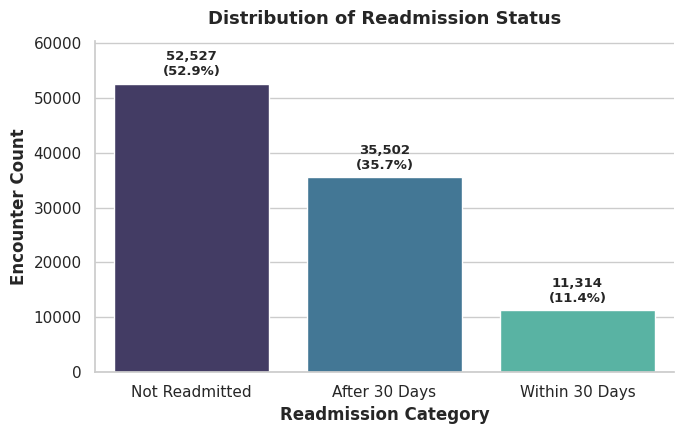

In [34]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))

correct_order = ["Not Readmitted", "After 30 Days", "Within 30 Days"]

ax = sns.countplot(
    data=diabetic_data,
    x="readmitted",
    palette="mako",
    order=correct_order
)

total = len(diabetic_data)

for c in ax.containers:
    labels = [f"{int(v):,}\n({v/total:.1%})" for v in c.datavalues]
    ax.bar_label(c, labels=labels, padding=4, fontweight="bold", fontsize=9.5)

plt.title("Distribution of Readmission Status", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Readmission Category", fontweight="bold")
plt.ylabel("Encounter Count", fontweight="bold")
plt.ylim(0, diabetic_data["readmitted"].value_counts().max() * 1.15)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Readmission Baseline Profile
1. Observation: Over half of the diabetic encounters (52.9%) do not result in a readmission, while a critical 11.4% (11,314 cases) return within the high-risk 30-day window.
2. Business Context: The 11.4% "Within 30 Days" segment is the primary KPI for this project. Since early readmissions often trigger financial penalties for hospitals, operational resources (like post-discharge follow-up calls) should be heavily targeted toward minimizing this specific group.

**Patients Age Distibution**

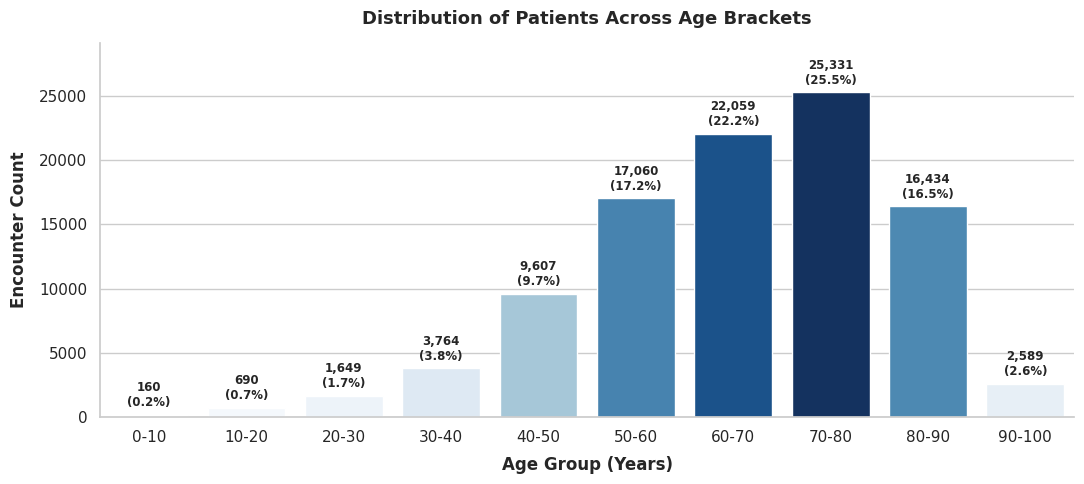

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 5))

age_order = [
    "0-10", "10-20", "20-30", "30-40", "40-50",
    "50-60", "60-70", "70-80", "80-90", "90-100"
]

# 1. Height ke hisaab se color map calculate karein
counts = diabetic_data['age'].value_counts().reindex(age_order).fillna(0)
norm = plt.Normalize(counts.min(), counts.max())
colors = plt.cm.Blues(norm(counts))

# 2. Plot with correct data-driven shading
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=colors
)

total = len(diabetic_data)

for c in ax.containers:
    labels = [f"{int(v):,}\n({v/total:.1%})" if v > 0 else "" for v in c.datavalues]
    ax.bar_label(c, labels=labels, padding=4, fontweight="bold", fontsize=8.5)

plt.title("Distribution of Patients Across Age Brackets", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Age Group (Years)", fontweight="bold", labelpad=8)
plt.ylabel("Encounter Count", fontweight="bold", labelpad=8)
plt.ylim(0, counts.max() * 1.15)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Patient Demographics
1. Aging Population Bias: The dataset is heavily skewed towards the elderly. Over 64% of all hospital admissions belong to patients aged 60 and above.
2. Peak Bracket: The 70-80 age group is the primary driver of hospital volume (25.5%).
3. Business Implication: High elderly volume means a higher likelihood of multiple comorbidities, longer recovery times, and heavy reliance on Medicare policies.

## Bivariate Analysis

**Time in Hospital vs Readmission**

In [36]:
# Groupwise full descriptive statistics
diabetic_data.groupby('readmitted')['time_in_hospital'].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
After 30 Days,35502.0,4.495521,2.988390,1.0,2.0,4.0,6.0,14.0
Not Readmitted,52527.0,4.217184,2.930331,1.0,2.0,3.0,6.0,14.0
Within 30 Days,11314.0,4.767545,3.027740,1.0,2.0,4.0,6.0,14.0


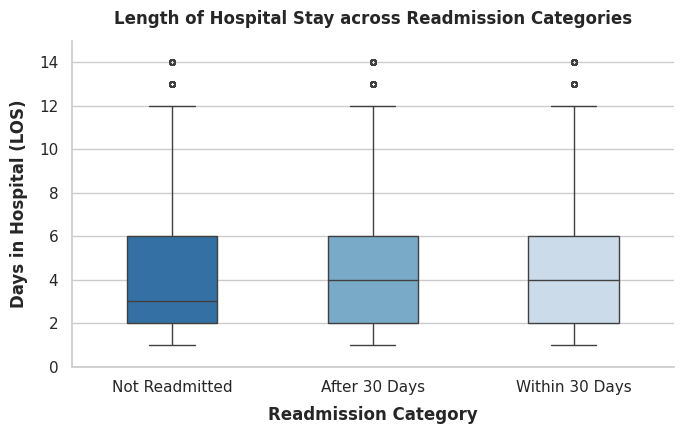

In [37]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))

order = ["Not Readmitted", "After 30 Days", "Within 30 Days"]

sns.boxplot(
    data=diabetic_data,
    x="readmitted",
    y="time_in_hospital",
    order=order,
    palette="Blues_r",
    width=0.45,
    flierprops={"marker": "o", "markersize": 3.5, "alpha": 0.25}  # Subtle outliers
)

plt.title("Length of Hospital Stay across Readmission Categories", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Readmission Category", fontweight="bold", labelpad=8)
plt.ylabel("Days in Hospital (LOS)", fontweight="bold", labelpad=8)
plt.ylim(0, 15)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Length of Stay (LOS) vs. Readmission Risk
* The "Null Finding": Contrary to common assumptions, longer hospital stays do not strongly predict early readmissions.
* Statistical Proof: The median length of stay is nearly identical across all groups (3 days for non-readmitted vs. 4 days for readmitted). The mean difference is statistically negligible (~0.5 days).
* Business Implication: Hospital administrators cannot rely on 'Days in Hospital' as a warning sign for readmission. Risk flags must be built on clinical metrics (like A1C results) or discharge destinations (like SNF), not just time spent in bed.

**Prior Inpatient Visits vs Readmission**

In [38]:
diabetic_data[diabetic_data["number_inpatient"] == 0].shape

(66245, 27)

In [39]:
# Normalized percentage table
prop_df = (
    pd.crosstab(
        diabetic_data['has_prior_inpatient'], 
        diabetic_data['readmitted'], 
        normalize='index'
    )[['Not Readmitted', 'After 30 Days', 'Within 30 Days']] * 100
)

prop_df

readmitted,Not Readmitted,After 30 Days,Within 30 Days
has_prior_inpatient,,,
0,60.756283,30.654389,8.589327
1,37.098918,45.909118,16.991963


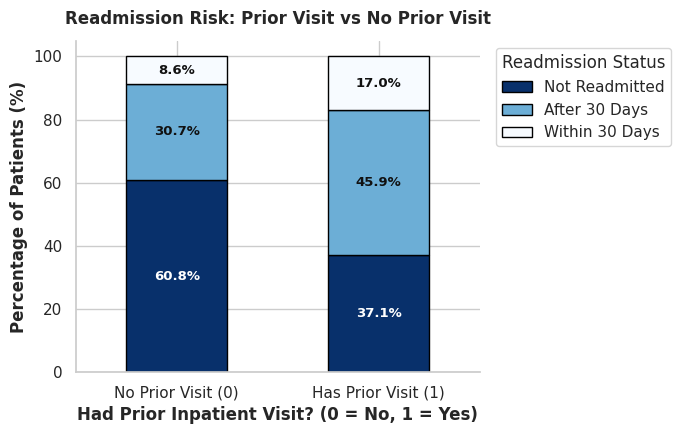

In [40]:
# Plot
ax = prop_df.plot(kind='bar', stacked=True, figsize=(7, 4.5), colormap='Blues_r', edgecolor='black')

plt.title("Readmission Risk: Prior Visit vs No Prior Visit", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Had Prior Inpatient Visit? (0 = No, 1 = Yes)", fontweight='bold')
plt.ylabel("Percentage of Patients (%)", fontweight="bold")
plt.xticks(ticks=[0, 1], labels=["No Prior Visit (0)", "Has Prior Visit (1)"], rotation=0)
plt.legend(title="Readmission Status", bbox_to_anchor=(1.02, 1), loc='upper left')

# Bar labels inside
for i, c in enumerate(ax.containers):
    # Pehla bar (Not Readmitted - Dark Blue) white text, baaki black text
    txt_color = 'white' if i == 0 else '#111111'
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontweight='bold', color=txt_color, fontsize=9.5)
    
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### The "Frequent Flyer" Risk* 
* The Multiplier Effect: A patient's history is the strongest predictor of future risk. Patients with at least one prior inpatient visit are twice as likely to be readmitted within 30 days (17.0%) compared to first-time patients (8.6%)
* Chronic Dependency: The non-readmission rate drops drastically from 60.8% to 37.1% if the patient has a history of prior visits.
* Business Implication: The hospital's IT system must automatically flag any incoming patient with a number_inpatient > 0. These patients require aggressive, specialized discharge planning to break the readmission loop.

**Medical Specialty vs Readmission**

In [41]:
specialty_readmit = pd.crosstab(diabetic_data['medical_specialty'], diabetic_data['readmitted'], normalize='index') * 100
specialty_readmit

readmitted,After 30 Days,Not Readmitted,Within 30 Days
medical_specialty,,,
Cardiology,35.101345,56.866831,8.031824
Emergency / Trauma,40.490632,48.119693,11.389675
Internal & General Medicine,34.352459,53.915957,11.731584
Obstetrics & Gynecology,16.472114,78.988327,4.539559
Other Specialists,31.934915,56.381102,11.683984
Pediatrics,28.896673,66.725044,4.378284
Surgery Department,30.644516,58.967174,10.388311
Unknown,37.399210,50.767237,11.833553


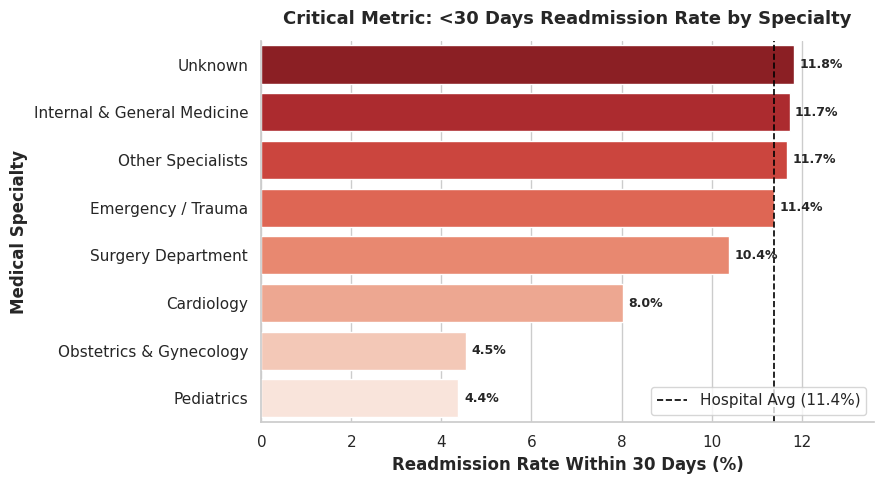

In [42]:
# Calculate only within-30-days rate
rate_30 = (
    pd.crosstab(
        diabetic_data['medical_specialty'], 
        diabetic_data['readmitted'], 
        normalize='index'
    )['Within 30 Days'] * 100
).sort_values(ascending=False).reset_index()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=rate_30,
    y='medical_specialty',
    x='Within 30 Days',
    palette='Reds_r'
)

# Annotations
for c in ax.containers:
    labels = [f"{v:.1f}%" for v in c.datavalues]
    ax.bar_label(c, labels=labels, padding=4, fontweight='bold', fontsize=9)

# Overall average line benchmark ke liye
avg_rate = (diabetic_data['readmitted'] == 'Within 30 Days').mean() * 100
plt.axvline(avg_rate, color='black', linestyle='--', linewidth=1.2, label=f'Hospital Avg ({avg_rate:.1f}%)')

plt.title("Critical Metric: <30 Days Readmission Rate by Specialty", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Readmission Rate Within 30 Days (%)", fontweight='bold')
plt.ylabel("Medical Specialty", fontweight='bold')
plt.xlim(0, rate_30['Within 30 Days'].max() * 1.15)
plt.legend(loc='lower right')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Departmental Performance & Data Quality
* **The Benchmark:** The overall hospital 30-day readmission rate is **11.4%**.
* **Data Quality Red Flag:** The highest readmission risk (**11.8%**) comes from patients with an 'Unknown' medical specialty. This indicates that poor record-keeping or lack of a dedicated specialist directly correlates with worse patient outcomes.
* **Top Performers:** Obstetrics & Gynecology (**4.5%**) and Pediatrics (**4.4%**) have the lowest risk profiles, which aligns with clinical expectations (younger/healthier demographics).
* **Business Implication:** Hospital administrators need to enforce **stricter documentation** to reduce **'Unknown'** specialties and audit the **'Internal & General Medicine'** department, which handles high volumes and sits slightly above the hospital average risk limit.

## Multivariate Analysis

**Resource Correlation**

In [43]:
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                  'num_medications', 'number_outpatient', 'number_emergency', 
                  'number_inpatient', 'number_diagnoses']

corr = diabetic_data[numerical_cols].corr()

# Upper triangle mask karke duplicate pairs aur self-correlation (1.0) hatana
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Absolute strength ke basis par sort karein
corr_summary = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

display(corr_summary[corr_summary['Correlation'] > 0])

,Feature 1,Feature 2,Correlation
0,time_in_hospital,num_medications,0.463757
1,num_procedures,num_medications,0.381931
2,time_in_hospital,num_lab_procedures,0.319855
3,number_emergency,number_inpatient,0.267702
4,num_lab_procedures,num_medications,0.265148
5,num_medications,number_diagnoses,0.261639
6,time_in_hospital,number_diagnoses,0.220600
7,time_in_hospital,num_procedures,0.189908
8,num_lab_procedures,number_diagnoses,0.149663
9,number_outpatient,number_inpatient,0.108015


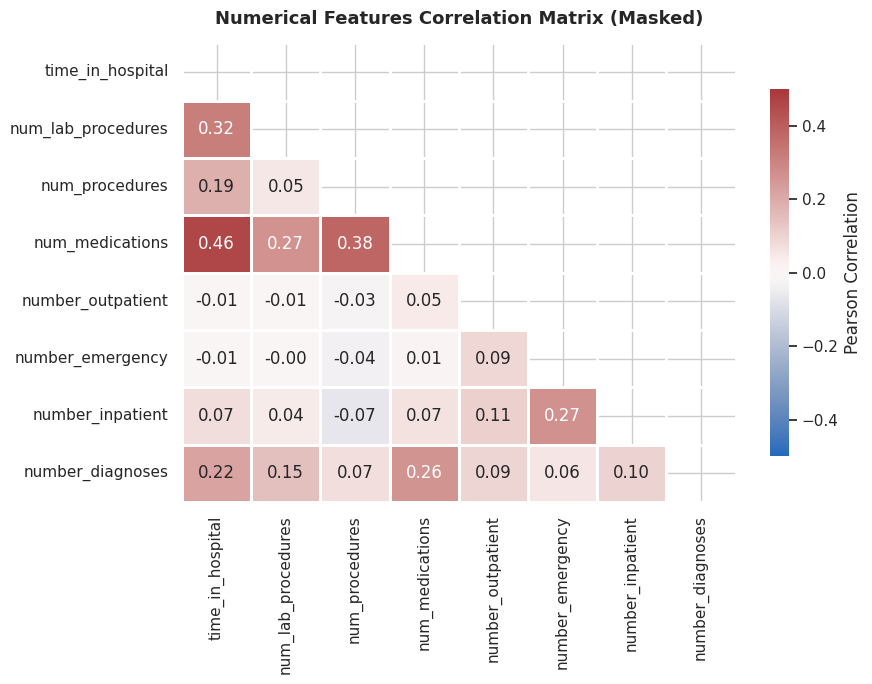

In [44]:
plt.figure(figsize=(9, 7))

# Selecting only numerical columns for correlation
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                  'num_medications', 'number_outpatient', 'number_emergency', 
                  'number_inpatient', 'number_diagnoses']

# Calculating correlation matrix
corr_matrix = diabetic_data[numerical_cols].corr()

# Upper triangle mask banayein
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Masked Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",       # Clean diverging palette
    vmin=-0.5,         # Data max/min range (-0.5 to 0.5) ke hisaab se scale adjust
    vmax=0.5,
    center=0,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
)

plt.title("Numerical Features Correlation Matrix (Masked)", fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

### Resource & Clinical Correlations
* **The Logical Link:** The strongest relationship in the dataset is between time_in_hospital and num_medications (Pearson = **0.46**), followed by num_procedures and num_medications (0.38). This validates clinical logic: longer stays and more surgeries naturally require more administered drugs.
* **Absence of Multicollinearity:** There are no highly correlated variables (i.e., > 0.75 or < -0.75). The relationships are generally weak to moderate.
* **Data Implication:** Because no two numerical features are perfectly mirroring each other, all of these variables provide unique, independent information. None of them need to be dropped for redundancy before SQL modeling or BI dashboarding.

# IMPORT SQLite3

In [45]:
import sqlite3

conn = sqlite3.connect("H&M_database.db")

In [46]:
diabetic_data.to_sql("diabetic_data", conn, if_exists="replace", index=False)
admission_type_df.to_sql("admission_type_df", conn, if_exists="replace", index=False)
admission_source_df.to_sql("admission_source_df", conn, if_exists="replace", index=False)
discharge_df.to_sql("discharge_df", conn, if_exists="replace", index=False)

7

# Problem Statement 📌

---

> ### **Executive Summary**
> The hospital faces substantial **financial penalties** and **operational strain** driven by elevated **30-day readmission rates** among diabetic patients. 
>
> High-risk patient profiles, departmental performance gaps, and unoptimized discharge protocols currently push readmissions beyond acceptable limits. The objective is to identify key clinical and operational risk drivers to bring readmission rates below the **`11.39%` hospital baseline**.

---

## Q1: Executive Scorecard - Core Operational and Clinical KPIs

### Extract the foundational hospital metrics to establish a performance baseline, calculating the total clinical encounters, unique patient volume, overall 30-day readmission rate, and average length of stay (LOS).

In [47]:
kpi = """
    SELECT 
        COUNT(encounter_id) AS total_encounters,
        COUNT(DISTINCT patient_nbr) AS total_unique_patients,
        SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) AS readmitted_within_30_days,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(*), 2) AS readmission_rate_pct,
        ROUND(AVG(time_in_hospital), 2) AS avg_stay_days
    FROM 
        diabetic_data;
"""

kpi = pd.read_sql_query(kpi, conn)
kpi

,total_encounters,total_unique_patients,readmitted_within_30_days,readmission_rate_pct,avg_stay_days
0,99343,69990,11314,11.39,4.38


### 📊 Executive Scorecard: Business Insights

---

* **Patient Volume:**&emsp;Processed `99,343` total encounters across `69,990` unique patients.
* **The "Repeat" Factor:**&emsp;The gap between encounters and unique patients indicates a `~29.5%` repeat-visit rate, showing heavy reliance on returning patients.
* **Critical Risk Metric:**&emsp;The overall 30-day readmission rate stands at `11.39%`.
* **Operational Metric:**&emsp;Patients stay an average of `4.38 days` per visit.

---

> ### 💡 Strategic Business Recommendation
> The **`11.39%`** readmission rate serves as the **absolute hospital baseline** for this analysis. Any clinical department or patient segment exceeding this threshold must be prioritized and flagged for an **immediate operational audit**.

## Q2: Demographic Impact - Age-Group Risk Profiling

### Analyze the distribution of patient volume across different age brackets and calculate their corresponding 30-day readmission rates to identify the most vulnerable demographic segments.

In [48]:
age_demo_drain = """
    SELECT
        age AS age_group,
        COUNT(encounter_id) AS total_patients,
        SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) AS readmitted_within_30_days,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) * 100.0) / COUNT(*), 2) AS readmitted_rate_pct
    FROM 
        diabetic_data
    GROUP BY
        age_group
    ORDER BY
        total_patients DESC;
"""

age_demo_drain = pd.read_sql_query(age_demo_drain, conn)
age_demo_drain

,age_group,total_patients,readmitted_within_30_days,readmitted_rate_pct
0,70-80,25331,3054,12.06
1,60-70,22059,2493,11.30
2,50-60,17060,1667,9.77
3,80-90,16434,2065,12.57
4,40-50,9607,1024,10.66
5,30-40,3764,424,11.26
6,90-100,2589,308,11.90
7,20-30,1649,236,14.31
8,10-20,690,40,5.80
9,0-10,160,3,1.88


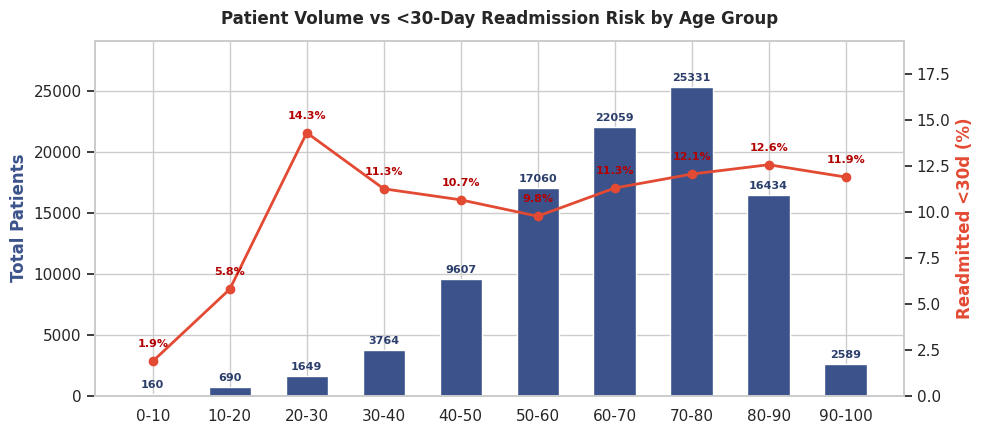

In [49]:
order = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100"]
df = age_demo_drain.set_index("age_group").reindex(order).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax2 = ax1.twinx()

# Volume Bars + Labels
bars = ax1.bar(df["age_group"], df["total_patients"], color="#3b528b", width=0.55)
ax1.bar_label(bars, fmt="%d", padding=3, fontsize=8, fontweight="bold", color="#2b3e6b")

# Rate Line + Labels
ax2.plot(df["age_group"], df["readmitted_rate_pct"], color="#e34a33", marker="o", lw=2)
for x, y in zip(df["age_group"], df["readmitted_rate_pct"]):
    ax2.annotate(f"{y:.1f}%", (x, y), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8, fontweight="bold", color="#b30000")

# Styling & Limits
ax1.set_ylabel("Total Patients", fontweight="bold", color="#3b528b")
ax2.set_ylabel("Readmitted <30d (%)", fontweight="bold", color="#e34a33")
ax1.set_ylim(0, df["total_patients"].max() * 1.15)
ax2.set_ylim(0, df["readmitted_rate_pct"].max() * 1.35)
ax2.grid(False)

plt.title("Patient Volume vs <30-Day Readmission Risk by Age Group", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### 📊 Age Demographics: Business Insights

---

* **The Financial Drain (High Volume + High Risk):**&emsp;Patients aged `70-90` are the primary drivers of readmission penalties, contributing over `5,100` readmitted patients combined (at a `~12.3%` failure rate).
* **The Clinical Anomaly:**&emsp;The `20-30` age group holds the highest relative risk (`14.3%`), though on a much smaller volume (`1,649 patients`).

---

> ### 💡 Strategic Action
> Direct primary post-care resources (follow-up calls, home nursing) towards the `70-90` demographic to maximize ROI and penalty reduction. Conduct a separate, targeted audit on the `20-30` group to understand the specific clinical failures in young adults.

## Q3: Medical Interventions - The Impact of Diabetes Medication
### Evaluate the correlation between prescribing diabetes medication and the 30-day readmission rate to assess the effectiveness of standard pharmacological interventions.

In [50]:
readmission_rate = """
    SELECT 
        diabetesMed AS prescribed_diabetes_med,
        COUNT(encounter_id) AS total_patients,
        SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) AS readmitted_within_30_days,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) * 100.0) / COUNT(*), 2) AS readmitted_rate_pct
    FROM diabetic_data
    GROUP BY diabetesMed;
"""
readmission_rate = pd.read_sql_query(readmission_rate, conn)
readmission_rate

,prescribed_diabetes_med,total_patients,readmitted_within_30_days,readmitted_rate_pct
0,No,22624,2233,9.87
1,Yes,76719,9081,11.84


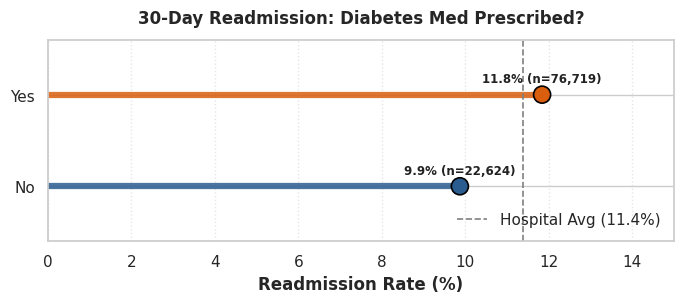

In [51]:
avg_rate = (diabetic_data['readmitted'] == 'Within 30 Days').mean() * 100
df = readmission_rate.sort_values(by="readmitted_rate_pct")
y, x, n = df["prescribed_diabetes_med"], df["readmitted_rate_pct"], df["total_patients"]

fig, ax = plt.subplots(figsize=(7, 3.2))
colors = ["#2b5c8f" if r < avg_rate else "#d95f0e" for r in x]

# Stems & Dots
ax.hlines(y=y, xmin=0, xmax=x, color=colors, lw=4.5, alpha=0.85)
ax.scatter(x, y, color=colors, s=150, zorder=3, edgecolors="black", lw=1.2)

# Benchmark Average Line
ax.axvline(avg_rate, color="gray", ls="--", lw=1.2, label=f"Hospital Avg ({avg_rate:.1f}%)")

# Label dot ke upar shift kiya taaki koi overlap na ho
for xi, yi, ni in zip(x, y, n):
    ax.annotate(f"{xi:.1f}% (n={ni:,})", (xi, yi), xytext=(0, 9), textcoords="offset points",
                ha="center", fontweight="bold", fontsize=8.5, color="#222222")

ax.set_ylim(-0.6, 1.6)
ax.set_xlim(0, 15)
ax.set_title("30-Day Readmission: Diabetes Med Prescribed?", fontweight="bold", pad=12)
ax.set_xlabel("Readmission Rate (%)", fontweight="bold")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

### 📊 Diabetes Medication: Business Insights

---

* **Data:**&emsp;Medicated patients have a higher readmission rate (`11.8%` vs `9.9%`).
* **Context:**&emsp;Meds don't cause readmission; they indicate sicker, high-risk patients.

---

> ### 💡 Strategic Action
> Mandate lifestyle tracking and strict follow-ups for all medicated discharges.

## Q4: Operational Bottlenecks - Discharge Destination Risk

### Calculate volume and 30-day readmission rates, identifying which discharge pathways carry the highest clinical risk.

In [52]:
discharge_risk = """
    SELECT 
        a.discharge_disposition_desc AS discharge_destination,
        COUNT(d.encounter_id) AS total_patients,
        SUM(CASE WHEN d.readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) AS readmitted_count,
        ROUND((SUM(CASE WHEN d.readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(d.encounter_id), 2) AS readmission_rate_pct
    FROM
        diabetic_data d
    INNER JOIN 
        discharge_df a 
        ON d.discharge_disposition_id = a.discharge_disposition_id
    GROUP BY
        a.discharge_disposition_desc
    HAVING 
        total_patients > 1000
    ORDER BY
        total_patients DESC;
"""

discharge_risk = pd.read_sql_query(discharge_risk, conn)
discharge_risk

,discharge_destination,total_patients,readmitted_count,readmission_rate_pct
0,Discharged to Home,73244,7255,9.91
1,Transferred to SNF/Rehab/Nursing,18469,3014,16.32
2,Unknown,4683,553,11.81
3,Transferred to Another Hospital,2139,342,15.99


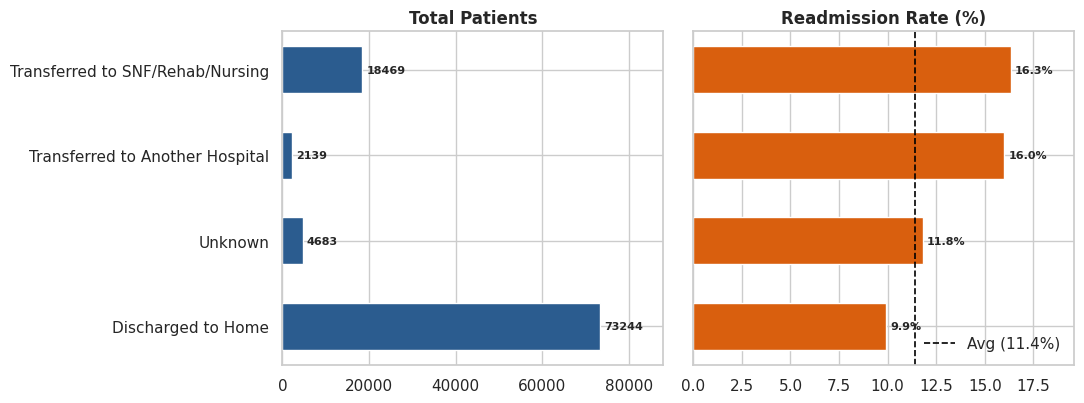

In [53]:
# Column rename safety & sort
df = discharge_risk.sort_values(by=discharge_risk.columns[3], ascending=True)
dest, vol, rate = df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

# 1. Volume
b1 = ax1.barh(dest, vol, color='#2b5c8f', height=0.55)
ax1.bar_label(b1, fmt='%d', padding=3, fontsize=8, fontweight='bold')
ax1.set_title("Total Patients", fontweight='bold')
ax1.set_xlim(0, vol.max() * 1.2)

# 2. Rate (%)
b2 = ax2.barh(dest, rate, color='#d95f0e', height=0.55)
ax2.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8, fontweight='bold')
ax2.axvline(11.4, color='black', ls='--', lw=1.2, label='Avg (11.4%)')
ax2.set_title("Readmission Rate (%)", fontweight='bold')
ax2.set_xlim(0, rate.max() * 1.2)
ax2.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

### 📊 Discharge Disposition: Business Insights

---

* **Safe Zone:**&emsp;`'Discharged to Home'` is the only high-volume category operating below the hospital penalty threshold (`9.9%`).
* **High-Risk Transfers:**&emsp;Patients transferred to `SNF/Rehab` facilities exhibit a severe readmission rate of `16.3%` (affecting `~18k` patients).

---

> ### 💡 Strategic Action
> Launch an immediate clinical audit of the partnered `SNF/Rehab` facilities. The hospital must ensure these third-party centers have proper post-discharge care protocols to prevent patients from bouncing back.

## Q5: Admission Source Risk - Does Point of Entry Matter?

### Evaluate readmission rates based on the patient's point of entry (e.g., Emergency Room vs. Referrals) to determine if acute admissions correlate with higher post-discharge failure rates.

In [54]:
admission_risk = """
    SELECT
        a.admission_source_desc AS admission_source,
        COUNT(d.encounter_id) AS total_patients,
        ROUND((SUM(CASE WHEN d.readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(d.encounter_id), 2) AS readmission_rate_pct
    FROM 
        diabetic_data d
    INNER JOIN 
        admission_source_df a
        ON d.admission_source_id = a.admission_source_id
    GROUP BY
        a.admission_source_desc
    HAVING
        total_patients > 500
    ORDER BY
        total_patients DESC;
"""

admission_risk = pd.read_sql_query(admission_risk, conn)
admission_risk

,admission_source,total_patients,readmission_rate_pct
0,Emergency Room,55850,11.98
1,Referral,30434,10.71
2,Unknown,6854,10.78
3,Transferred from another facility,6185,10.07


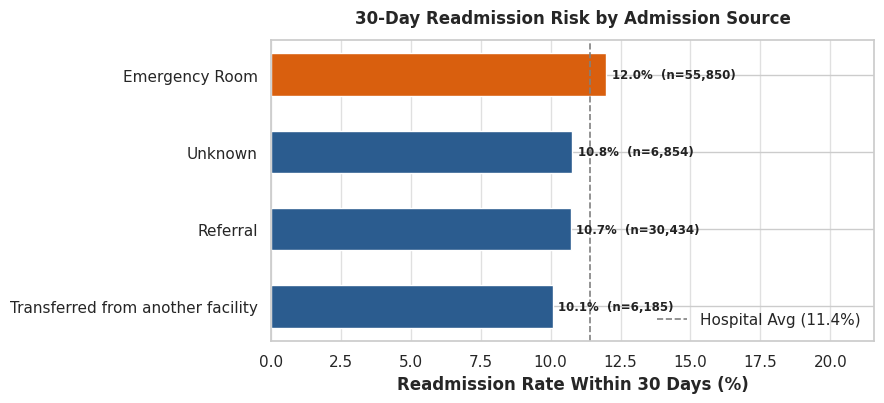

In [55]:
df = admission_risk.sort_values(by="readmission_rate_pct", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
avg_rate = (diabetic_data['readmitted'] == 'Within 30 Days').mean() * 100
ax.axvline(avg_rate, color="gray", linestyle="--", lw=1.2, label=f"Hospital Avg ({avg_rate:.1f}%)")

colors = ["#2b5c8f" if r < avg_rate else "#d95f0e" for r in df["readmission_rate_pct"]]
bars = ax.barh(df["admission_source"], df["readmission_rate_pct"], color=colors, height=0.55)

# Rate + Sample size label (n=...) taaki small sample bias saaf dikhe
labels = [f"{r:.1f}%  (n={n:,})" for r, n in zip(df["readmission_rate_pct"], df["total_patients"])]
ax.bar_label(bars, labels=labels, padding=4, fontweight="bold", fontsize=8.5, color="#222222")

ax.set_title("30-Day Readmission Risk by Admission Source", fontweight="bold", fontsize=12, pad=12)
ax.set_xlabel("Readmission Rate Within 30 Days (%)", fontweight="bold")
ax.set_xlim(0, df["readmission_rate_pct"].max() * 1.80)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="x", linestyle="-", alpha=0.6)

plt.tight_layout()
plt.show()

### 📊 Admission Source: Business Insights

---

* **The ER Drain:**&emsp;The `'Emergency Room'` handles the highest patient volume (`~55k`) and holds the highest readmission rate (`12.0%`).
* **Controlled Entry:**&emsp;Planned admissions via `'Referral'` perform significantly better (`10.7%`) and remain safely below the hospital benchmark.

---

> ### 💡 Strategic Action
> ER patients are stabilized quickly but may be discharged prematurely. Mandate a mandatory "Secondary Clinical Review" for all ER-admitted diabetic patients before authorizing discharge.

## Q6: Behavioral Patterns - The "Frequent Flyer" Impact

### Segment the patient population based on historical hospital utilization (new vs. returning patients) to evaluate how prior inpatient visits compound the risk of 30-day readmissions.

In [56]:
ff_risk = """
    SELECT
        CASE
            WHEN has_prior_inpatient = 0 THEN 'New Patients (0 prior visit)'
            ELSE 'Frequent Flyers (>0 prior visit)'
        END AS patient_segment,
        COUNT(encounter_id) AS total_patients,
        SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) AS readmitted_count,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(encounter_id), 2) AS readmission_rate_pct
    FROM 
        diabetic_data
    GROUP BY
        patient_segment
    ORDER BY
        readmission_rate_pct DESC;
"""

ff_risk = pd.read_sql_query(ff_risk, conn)
ff_risk

,patient_segment,total_patients,readmitted_count,readmission_rate_pct
0,Frequent Flyers (>0 prior visit),33098,5624,16.99
1,New Patients (0 prior visit),66245,5690,8.59


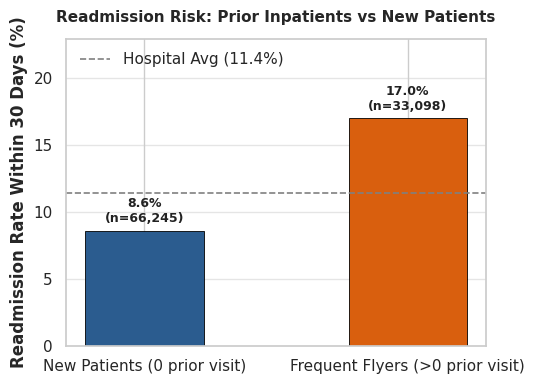

In [57]:
df = ff_risk.sort_values(by="readmission_rate_pct", ascending=True)

fig, ax = plt.subplots(figsize=(5.5, 4))
avg_rate = (diabetic_data['readmitted'] == 'Within 30 Days').mean() * 100
ax.axhline(avg_rate, color="gray", linestyle="--", lw=1.2, label=f"Hospital Avg ({avg_rate:.1f}%)")

colors = ["#2b5c8f", "#d95f0e"]  # Safe blue vs High risk orange
bars = ax.bar(df["patient_segment"], df["readmission_rate_pct"], color=colors, width=0.45, edgecolor="black", lw=0.6)

# Labels with rate and total patient count (n=...)
labels = [f"{r:.1f}%\n(n={n:,})" for r, n in zip(df["readmission_rate_pct"], df["total_patients"])]
ax.bar_label(bars, labels=labels, padding=4, fontweight="bold", fontsize=9, color="#222222")

ax.set_title("Readmission Risk: Prior Inpatients vs New Patients", fontweight="bold", fontsize=11, pad=12)
ax.set_ylabel("Readmission Rate Within 30 Days (%)", fontweight="bold")
ax.set_ylim(0, df["readmission_rate_pct"].max() * 1.35)
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.show()

### 📊 Prior Utilization: Business Insights

---

* **The Baseline:**&emsp;`'New Patients'` represent the bulk of hospital traffic (`~66k`) but operate well within safe margins (`8.6%` readmission rate).
* **The Multiplier Effect:**&emsp;The readmission rate virtually doubles to `17.0%` for `'Frequent Flyers'` (patients with at least one prior visit).

---

> ### 💡 Strategic Action
> Automate IT flags in the Electronic Health Record (`EHR`) system. Any patient admitted with a history of prior visits must automatically trigger a specialized, high-touch discharge planning protocol.

## Q7: Time & Risk - Length of Stay (LOS) vs Readmission Benchmark

### Group patient stays into logical clinical duration buckets (short, medium, long) to determine if prolonged hospital stays correlate with elevated readmission penalties.

In [58]:
LOS_readmission_rate = """
    SELECT 
        CASE
            WHEN time_in_hospital BETWEEN 1 AND 4 THEN '1-4 Days stay'
            WHEN time_in_hospital BETWEEN 5 AND 8 THEN '5-8 Days stay'
            ELSE '9+ Days stay'
        END AS stay_time_group,
        COUNT(encounter_id) AS total_patients,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / count(encounter_id), 2) AS readmission_rate_pct
    FROM 
        diabetic_data
    GROUP BY
        stay_time_group
    ORDER BY
        stay_time_group;
"""

LOS_readmission_rate = pd.read_sql_query(LOS_readmission_rate, conn)
LOS_readmission_rate

,stay_time_group,total_patients,readmission_rate_pct
0,1-4 Days stay,61831,10.33
1,5-8 Days stay,27071,12.97
2,9+ Days stay,10441,13.54


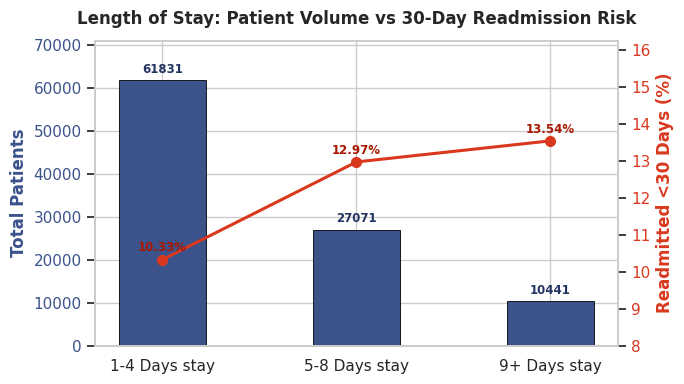

In [59]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

# 1. Volume Bars
bars = ax1.bar(LOS_readmission_rate['stay_time_group'], LOS_readmission_rate['total_patients'], color='#3b528b', width=0.45, edgecolor='black', lw=0.6)
ax1.bar_label(bars, fmt='%d', padding=3, fontweight='bold', fontsize=8.5, color='#223561')
ax1.set_ylabel("Total Patients", fontweight='bold', color='#3b528b')
ax1.tick_params(axis='y', labelcolor='#3b528b')
ax1.set_ylim(0, LOS_readmission_rate['total_patients'].max() * 1.15)

# 2. Risk Rate Line
ax2.plot(LOS_readmission_rate['stay_time_group'], LOS_readmission_rate['readmission_rate_pct'], color='#d9381e', marker='o', lw=2.2, markersize=7)
for x, y in zip(range(len(LOS_readmission_rate)), LOS_readmission_rate['readmission_rate_pct']):
    ax2.annotate(f"{y:.2f}%", (x, y), xytext=(0, 6), textcoords="offset points", ha='center', fontweight='bold', fontsize=8.5, color='#a81800')

ax2.set_ylabel("Readmitted <30 Days (%)", fontweight='bold', color='#d9381e')
ax2.tick_params(axis='y', labelcolor='#d9381e')
ax2.set_ylim(8, LOS_readmission_rate['readmission_rate_pct'].max() * 1.2)
ax2.grid(False)

plt.title("Length of Stay: Patient Volume vs 30-Day Readmission Risk", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 📊 Length of Stay: Business Insights

---

* **The Trend:**&emsp;Readmission risk increases alongside the length of stay, rising from `10.33%` (`1-4 days`) to `13.54%` (`9+ days`).
* **Volume Context:**&emsp;The vast majority of patients (`~61k`) are discharged quickly (`1-4 days`) and stay below the penalty threshold.

---

> ### 💡 Strategic Action
> Prolonged stays (`>5 days`) are an indicator of complex, high-risk cases, not just slow recovery. Implement specialized discharge planning for any patient crossing the `4-day` mark.

## Q8: Strategic Intervention - Medical Specialty Audit

### Evaluate clinical departments to identify the top three high-volume medical specialties (handling over 1,000 patient encounters) that are currently operating above the baseline hospital readmission rate.

In [60]:
medical_spec_audit = """
    WITH hospital_avg AS (
        SELECT 
            ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(*), 2) AS overall_avg
        FROM 
            diabetic_data
    )
    SELECT 
        medical_specialty,
        COUNT(encounter_id) AS total_patients,
        SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END) AS readmitted_count,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(encounter_id), 2) AS readmission_rate_pct
    FROM 
        diabetic_data
    GROUP BY
        medical_specialty
    HAVING
        total_patients > 1000
        AND readmission_rate_pct > (SELECT overall_avg FROM hospital_avg)
    ORDER BY
        readmission_rate_pct DESC
    LIMIT 3;
"""

medical_spec_audit = pd.read_sql_query(medical_spec_audit, conn)
medical_spec_audit

,medical_specialty,total_patients,readmitted_count,readmission_rate_pct
0,Unknown,48616,5753,11.83
1,Internal & General Medicine,21489,2521,11.73
2,Other Specialists,10202,1192,11.68


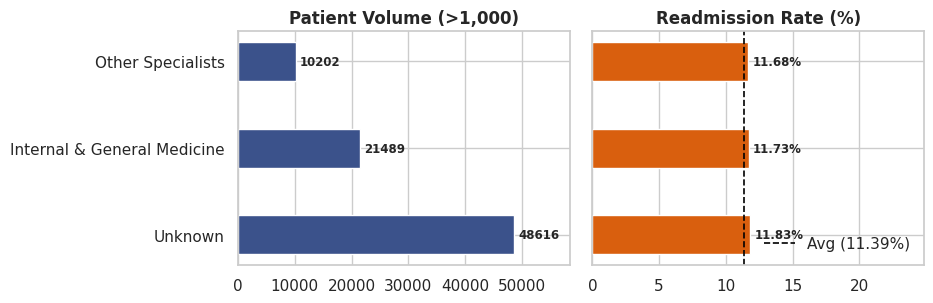

In [61]:
avg_rate = (diabetic_data['readmitted'] == 'Within 30 Days').mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)

# 1. Volume
b1 = ax1.barh(medical_spec_audit["medical_specialty"], medical_spec_audit["total_patients"], color="#3b528b", height=0.45)
ax1.bar_label(b1, fmt="%d", padding=3, fontweight="bold", fontsize=8.5)
ax1.set_title("Patient Volume (>1,000)", fontweight="bold")
ax1.set_xlim(0, medical_spec_audit["total_patients"].max() * 1.2)

# 2. Risk Rate (%)
b2 = ax2.barh(medical_spec_audit["medical_specialty"], medical_spec_audit["readmission_rate_pct"], color="#d95f0e", height=0.45)
ax2.bar_label(b2, fmt="%.2f%%", padding=3, fontweight="bold", fontsize=8.5)
ax2.axvline(avg_rate, color="black", ls="--", lw=1.2, label=f"Avg ({avg_rate:.2f}%)")
ax2.set_title("Readmission Rate (%)", fontweight="bold")
ax2.set_xlim(0, medical_spec_audit["readmission_rate_pct"].max() * 2.1)
ax2.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

### 📊 Medical Specialty: Business Insights

---

* **The Data Gap:**&emsp;A massive concentration of `~48,000` patient encounters is logged under `'Unknown'` specialty, failing the baseline at `11.83%` readmission rate. This reflects a critical failure in EHR intake validation.
* **Underperforming Units:**&emsp;Both `Internal & General Medicine` (`11.73%`) and `Other Specialists` (`11.68%`) consistently breach the hospital baseline average (`11.39%`), driving the vast majority of preventable readmissions.

---

> ### 💡 Strategic Action
> Enforce strict form-level validation in the Electronic Health Record (`EHR`) system to strictly block `'Unknown'` physician entries at patient admission. Deploy a targeted clinical audit specifically for the **Internal Medicine** discharge pipeline.

## Q9: Resource Allocation - The Cost of Clinical Complexity

### Develop a resource utilization matrix to compare the average consumption of clinical services (lab procedures, medications, and diagnoses) across patient readmission outcomes, identifying if high-risk patients exhibit higher initial resource dependency.

In [62]:
resource_df = """
    SELECT 
        readmitted as readmission_status,
        COUNT(encounter_id) AS total_patients,
        ROUND(AVG(num_lab_procedures), 1) AS avg_lab_procedures,
        ROUND(AVG(num_medications), 1) AS avg_medications,
        ROUND(AVG(number_diagnoses), 1) AS avg_diagnoses
    FROM 
        diabetic_data
    GROUP BY
        readmission_status
    ORDER BY
        total_patients DESC;
"""

resource_df = pd.read_sql_query(resource_df, conn)
resource_df

,readmission_status,total_patients,avg_lab_procedures,avg_medications,avg_diagnoses
0,Not Readmitted,52527,42.0,15.6,7.2
1,After 30 Days,35502,43.8,16.3,7.6
2,Within 30 Days,11314,44.2,16.9,7.7


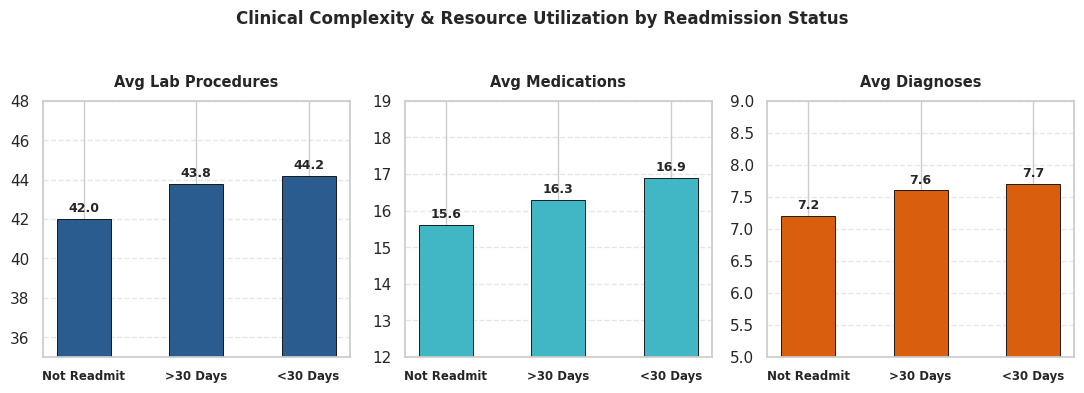

In [63]:
order = ['Not Readmitted', 'After 30 Days', 'Within 30 Days']
df = resource_df.set_index('readmission_status').reindex(order).reset_index()

metrics = [
    ('avg_lab_procedures', 'Avg Lab Procedures', '#2b5c8f', (35, 48)),
    ('avg_medications', 'Avg Medications', '#41b6c4', (12, 19)),
    ('avg_diagnoses', 'Avg Diagnoses', '#d95f0e', (5, 9))
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharex=True)

for ax, (col, title, color, ylim) in zip(axes, metrics):
    bars = ax.bar(df['readmission_status'], df[col], color=color, width=0.48, edgecolor='black', lw=0.6)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontweight='bold', fontsize=9)
    ax.set_title(title, fontweight='bold', pad=10, fontsize=10.5)
    ax.set_ylim(ylim)
    ax.set_xticklabels(['Not Readmit', '>30 Days', '<30 Days'], fontweight='bold', fontsize=8.5)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Clinical Complexity & Resource Utilization by Readmission Status", fontweight='bold', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

### 📊 Resource Utilization: Business Insights

---

* **The Complexity Cost:**&emsp;Patients who fail post-discharge (readmitted `<30 days`) consistently consumed more resources during their initial stay (averaging `44.2` labs and `16.9` medications).
* **Early Warning Indicator:**&emsp;A higher initial resource drain is a direct proxy for clinical complexity and elevated readmission risk.

---

> ### 💡 Strategic Action
> Program a "Resource Threshold Flag" into the hospital system. If a patient's treatment exceeds `40 lab procedures` or `16 medications`, mandate a senior physician's sign-off before discharge.

## Q10: Feature Engineering - The Clinical Severity Index

### Develop a custom clinical severity index by categorizing patients based on their total number of diagnoses, and evaluate how this engineered metric correlates with 30-day readmission vulnerability.

In [64]:
severity_df = """
    SELECT 
        CASE 
            WHEN number_diagnoses < 5 THEN 'Low Severity (<5)'
            WHEN number_diagnoses BETWEEN 5 AND 8 THEN 'Medium Severity (5-8)'
            ELSE 'High Severity (>8)'
        END AS severity_score,
        COUNT(encounter_id) AS total_patients,
        ROUND((SUM(CASE WHEN readmitted = 'Within 30 Days' THEN 1 ELSE 0 END)*100.0) / COUNT(encounter_id), 2) AS readmission_rate_pct
    FROM 
        diabetic_data
    GROUP BY
        severity_score
    ORDER BY
        total_patients
"""


severity_df = pd.read_sql_query(severity_df, conn)
severity_df

,severity_score,total_patients,readmission_rate_pct
0,Low Severity (<5),9563,7.75
1,Medium Severity (5-8),41861,10.64
2,High Severity (>8),47919,12.77


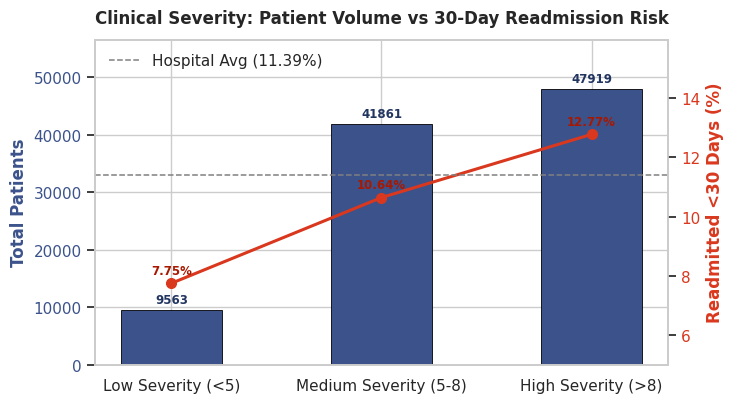

In [65]:
avg_rate = (diabetic_data['readmitted'] == 'Within 30 Days').mean() * 100

# Natural severity order
order = ['Low Severity (<5)', 'Medium Severity (5-8)', 'High Severity (>8)']
df = severity_df.set_index('severity_score').reindex(order).reset_index()

fig, ax1 = plt.subplots(figsize=(7.5, 4.2))
ax2 = ax1.twinx()

# 1. Volume Bars
bars = ax1.bar(df['severity_score'], df['total_patients'], color='#3b528b', width=0.48, edgecolor='black', lw=0.6)
ax1.bar_label(bars, fmt='%d', padding=3, fontweight='bold', fontsize=8.5, color='#223561')
ax1.set_ylabel("Total Patients", fontweight='bold', color='#3b528b')
ax1.tick_params(axis='y', labelcolor='#3b528b')
ax1.set_ylim(0, df['total_patients'].max() * 1.18)

# 2. Risk Rate Line
ax2.plot(df['severity_score'], df['readmission_rate_pct'], color='#d9381e', marker='o', lw=2.2, markersize=7)
for x, y in zip(range(len(df)), df['readmission_rate_pct']):
    ax2.annotate(f"{y:.2f}%", (x, y), xytext=(0, 7), textcoords="offset points", ha='center', fontweight='bold', fontsize=8.5, color='#a81800')

ax2.axhline(avg_rate, color='gray', linestyle='--', lw=1.1, label=f"Hospital Avg ({avg_rate:.2f}%)")
ax2.set_ylabel("Readmitted <30 Days (%)", fontweight='bold', color='#d9381e')
ax2.tick_params(axis='y', labelcolor='#d9381e')
ax2.set_ylim(5, df['readmission_rate_pct'].max() * 1.25)
ax2.legend(loc='upper left', frameon=False)
ax2.grid(False)

plt.title("Clinical Severity: Patient Volume vs 30-Day Readmission Risk", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 📊 Clinical Severity: Business Insights

---

* **Direct Correlation:**&emsp;Readmission risk scales strictly linearly with clinical severity, peaking at `12.77%` for high-severity patients (`>8 diagnoses`).
* **The Volume Danger:**&emsp;The hospital is heavily skewed towards complex cases. The absolute largest patient cohort (`~48k patients`) falls into the highest risk bracket.

---

> ### 💡 Strategic Action
> Integrate this Severity Score directly into the admission triage system. Automatically assign specialized case managers to `'High Severity'` patients on day one to preemptively manage their complex discharge needs.

# 🎯 Final Executive Recommendations

---

> ### **1. Automate EHR Alerts for 'Frequent Flyers'**
> Patient history is the strongest risk multiplier. Patients with prior inpatient visits fail at a `17.0%` rate (double the baseline). IT must implement automatic `EHR` flags forcing a specialized discharge review for any returning patient.

> ### **2. Audit SNF/Rehab Transfer Protocols**
> Patients transferred to Skilled Nursing Facilities (`SNF`) or Rehab centers carry a severe `16.3%` readmission rate. The hospital must immediately audit its third-party facility partners to ensure they possess capable post-discharge diabetic care protocols.

> ### **3. Implement a 'Complexity' Discharge Threshold**
> High clinical severity (`>8 diagnoses`) and high initial resource consumption (`>40 lab procedures` / `16 meds`) directly predict failure. Mandate a senior physician's sign-off and assign dedicated case managers to these high-severity cohorts before authorizing discharge.

> ### **4. Fix 'Unknown' Data Capture at Triage**
> Over `48,000` encounters are operating at an `11.8%` failure rate under an `'Unknown'` medical specialty, completely masking departmental accountability. Implement hard stops in the admission software to ensure `100%` accurate physician specialty logging.